In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.svm import SVR, SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


# Show all columns when printing
pd.set_option('display.max_columns', None)

In [38]:
df = pd.read_csv('src/data/training/processed/final_training_data.csv')

In [3]:
target_cols = df.filter(regex='^(dn__|ul__|mv__|madrid__|ep__|cb__|ob__|ab__)').columns

missing_or_zero = df[target_cols].isna() | (df[target_cols] == 0)

missing_fraction = missing_or_zero.mean(axis=1)

df = df[missing_fraction <= 0.8].copy()

In [39]:
#df = df[df['reference_date']>='2024-01-01']

In [40]:
df.shape

(15211, 75)

In [41]:
df

,user_id,reference_date,ob__limit_ref,ob__balance_ref,ob__avg_util_ref,ob__open_limit_ref,t__is_drawn,t__ccf,mv__is_lisbon_v1,mv__is_lisbon_v2,mv__is_lisbon_v3,mv__is_lisbon_v4,mv__is_porto_v1,mv__is_porto_v2,ef__is_covid,gender,nationality,sd__age,sd__age_since_first_kyc,sd__age_since_last_kyc,sd__membership_product,sd__max_daily_logins_6m,sd__max_daily_logins_12m,madrid__avg_monthly_salary_3m,madrid__avg_monthly_expenses_3m,madrid__avg_monthly_repayment_capacity_3m,ul__is_expat,od__history_length_days,od__is_history,ob__avg_util_3m,ob__avg_util_change_3m,ob__max_util_3m,ob__max_util_change_3m,ob__std_util_3m,ob__std_util_change_3m,ob__util_slope_3m,ob__util_range_3m,ob__num_od_entries_6m,ob__num_od_exits_6m,ob__overlimit_days_6m,ob__full_repayment_events_6m,ob__max_consecutive_od_days_since_creation_ratio,ob__od_draw_days_6m,ob__od_enabled_zero_util_days_6m,ob__technical_od_days_6m,ob__technical_od_deep_days_6m,ob__avg_util_first_2m_since_creation,ob__avg_util_change_last2m_to_first2m,ob__avg_util_first2m_1y,ob__avg_util_change_last2m_to_first2m_1y,ob__max_consecutive_overlimit_days_since_creation_ratio,ob__partial_repayment_events_6m,ob__full_repayment_change_3m_vs_prev_3m,ob__util_last2m_to_first2m_ratio,ob__util_last2m_to_first2m_1y_ratio,ob__max_to_avg_util_3m_ratio,ab__avg_bal_3m,ab__avg_bal_change_3m,ab__max_util_3m,ab__max_bal_change_3m,ab__std_util_3m,ab__std_bal_change_3m,ab__bal_changed_3m,ab__bal_change_freq_3m,ab__mean_abs_change_6m,ab__std_abs_change_6m,ab__max_one_day_drop_6m,ab__inflow_spike_count_6m,ab__days_down_6m,ab__near_zero_days_6m,dn__recent_action,dn__max_action_level,cb__most_recent_score,cb__worst_score,ep__cc_tbil_balance
0,e71e8a98-7408-4a0a-9ffb-aa634d49e6a9,2023-08-21,6000.0,5998.78,0.99980,0.00020,1,1.00000,1,0,0,0,0,0,0,1.0,6.0,40,2017.0,2017.0,7.0,30.0,30.0,0.00,0.000000,1169.000000,0,2018,1,1.007732,0.015231,1.029796,0.030621,0.022957,-0.014908,2.739301e-09,0.188728,0,0,56,0,0.0,181,0,0,0,0.739344,0.275498,1.006010,0.008832,0.0,6,0,1.3726,1.0087,1.0218,-6046.395604,-91.389398,-5046.41,-952.37,137.744446,-8.944555e+01,1,4,56.875083,348.784107,-3384.51,3,6,0,1.0,90.0,3.0,3.0,0.0
1,e928e2e6-531b-4e23-928e-613c8d622dfd,2024-07-30,250.0,0.00,0.00000,1.00000,1,0.14040,0,0,0,0,1,0,0,0.0,96.0,45,150.0,150.0,7.0,7.0,7.0,0.00,0.000000,10.000000,1,136,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2,2,9,2,0.0,19,117,0,0,0.234047,-0.234047,NaN,NaN,0.0,0,-2,0.0000,NaN,NaN,2.112198,-0.610000,2.32,-0.61,0.290700,4.689331e-16,1,1,17.201000,90.570267,-590.49,3,6,124,10.0,10.0,2.0,2.0,0.0
2,eaaee9d7-3aea-4a4c-aaa3-65c2c1b4191f,2022-12-07,500.0,0.00,0.00000,1.00000,1,1.00000,1,0,0,0,0,0,0,1.0,27.0,27,2224.0,2224.0,6.0,7.0,7.0,0.00,607.000000,1881.333333,0,2225,1,0.163381,-0.479873,0.729000,-0.713720,0.299839,-0.341119,-7.610887e-08,0.729000,3,4,0,4,0.0,46,135,0,0,0.000000,0.006275,0.433903,-0.427628,0.0,1,2,NaN,0.0144,4.4619,232.568022,1059.584624,3492.36,3412.86,904.980947,1.130881e+03,1,20,57.020552,356.241185,-3063.00,5,19,46,NaN,NaN,4.0,4.0,0.0
3,ed03a294-1ebb-473b-97e8-5a0abab56b8d,2018-11-27,250.0,0.00,0.00000,1.00000,0,0.00000,1,0,0,0,0,0,0,1.0,27.0,29,505.0,505.0,2.0,12.0,19.0,10311.25,25706.363333,24658.186667,0,1,1,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,0,0,0,0,NaN,0,1,0,0,0.000000,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,1139.883626,656.021624,4717.45,2087.02,1105.999238,7.997399e+02,1,69,529.733204,912.332390,-3813.61,40,84,1,NaN,NaN,6.0,7.0,0.0
4,f0560a88-6dbd-4c5c-965d-9c6dc11ab2a0,2022-02-08,500.0,0.00,0.00000,1.00000,1,0.26204,1,0,0,0,0,0,0,1.0,125.0,25,111.0,111.0,7.0,2.0,2.0,0.00,43.046667,88.163333,1,1,1,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000e+00,0.000000,0,0,0,0,NaN,0,1,0,0,0.000000,0.000000,NaN,NaN,NaN,0,0,NaN,NaN,NaN,62.708022,75.536720,172.30,121.21,53.587515,5.436521e+01,1,24,6.938919,19.735941,-61.58,0,21,42,NaN,NaN,7.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [2563]:
cols_to_drop = [
    'mv__is_lisbon_v3', 'ep__is_cc_tbil', 
    'mv__is_lisbon_v4', 'mv__is_porto_v1', 'ab__bal_changed_1m', 
    'mv__is_lisbon_v2', 'mv__is_porto_v2', 'ul__is_deu', 
    'ob__full_repayment_events_6m', 'ul__is_aut',
    'ob__num_od_exits_6m', 'ob__num_od_entries_6m',
    'ul__is_expat', 'ep__is_cc', 'ep__is_tbil'
]

# Drop columns from df
df = df.drop(columns=cols_to_drop)

In [42]:
df['mix__sd_od_history_to_kyc_ratio'] = df['od__history_length_days'] / df['sd__age_since_first_kyc']

In [43]:
#df = df[df['t__ccf']>0]

In [44]:
df.drop(columns=['user_id', 'reference_date', 'od__history_length_days', 'od__is_history'], inplace=True)

In [11]:
sampled_df = df.sample(frac=0.2, random_state=42)

remaining_df = df.drop(sampled_df.index)
#remaining_df = remaining_df[remaining_df['t__ccf']>0]

In [12]:
y_realized = sampled_df['t__ccf']
y_realized = y_realized.clip(upper=2)
sampled_df = sampled_df.drop(columns=['t__ccf', 't__is_drawn'])

In [45]:
y_reg = df['t__ccf']
y_clf = df['t__is_drawn']

X = df

In [2489]:
caps = X.quantile(0.9)

X = X.clip(upper=caps, axis=1)

In [46]:
reg_feats = ['t__ccf',
'ob__limit_ref',
 'ob__max_to_avg_util_3m_ratio',
 'ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__max_util_3m',
 'ob__avg_util_3m',
 'madrid__avg_monthly_expenses_3m',
 'ob__od_enabled_zero_util_days_6m',
 'ob__partial_repayment_events_6m',
 'mix__sd_od_history_to_kyc_ratio',
 'sd__age_since_last_kyc',
 'ab__std_abs_change_6m',
 'sd__age',
 'ob__util_last2m_to_first2m_1y_ratio',
 'sd__max_daily_logins_12m',
 'ob__std_util_3m',
 'ab__bal_change_freq_3m',
 'ob__od_draw_days_6m',
 'sd__max_daily_logins_6m',
 'sd__age_since_first_kyc',
 'madrid__avg_monthly_salary_3m',
 'ab__max_one_day_drop_6m',
 'cb__worst_score',
 'mv__is_lisbon_v1',
 'ul__is_expat',
 'ab__inflow_spike_count_6m',
 'ob__util_range_3m',
 'ob__avg_util_change_last2m_to_first2m_1y',
 'madrid__avg_monthly_repayment_capacity_3m',
 'sd__membership_product']
clf_feats = ['ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__limit_ref',
 'madrid__avg_monthly_salary_3m',
 'ul__is_expat',
 'ob__od_enabled_zero_util_days_6m',
 'madrid__avg_monthly_expenses_3m',
 'sd__age',
 'ob__max_to_avg_util_3m_ratio',
 'ob__max_util_change_3m',
 'sd__max_daily_logins_6m',
 'ab__avg_bal_3m',
 'cb__worst_score',
 'mix__sd_od_history_to_kyc_ratio',
 'ab__days_down_6m',
 'ab__inflow_spike_count_6m',
 'sd__max_daily_logins_12m',
 'ab__std_abs_change_6m',
 'ab__std_bal_change_3m',
 'ab__near_zero_days_6m',
 'ab__bal_change_freq_3m',
 'ep__cc_tbil_balance',
 'madrid__avg_monthly_repayment_capacity_3m',
 'ab__max_bal_change_3m',
 'ob__util_last2m_to_first2m_ratio',
 'ab__avg_bal_change_3m',
 'ob__avg_util_3m',
 'ab__max_one_day_drop_6m',
 'mv__is_lisbon_v1',
 'ob__partial_repayment_events_6m']

In [47]:
# Split 80-20
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [48]:
X_train_reg = X_train[reg_feats]
X_test_reg = X_test[reg_feats]

X_train_reg = X_train_reg[X_train_reg['t__ccf'] > 0]
y_train_reg = y_train_reg[y_train_reg > 0]

X_train_reg = X_train_reg.drop(columns=['t__ccf'])
X_test_reg = X_test_reg.drop(columns=['t__ccf'])

X_train_clf = X_train[clf_feats]
X_test_clf = X_test[clf_feats]

In [49]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
X_train['ob__open_limit_ref']

1264     1.00000
1832     0.06111
2330     0.01468
12484    0.15480
7833     1.00000
          ...   
8293     0.23856
7510     0.06884
7810     0.06204
1250     1.00000
10541    0.13106
Name: ob__open_limit_ref, Length: 8424, dtype: float64

In [10]:
lin_reg = LinearRegression().fit(X_train_scaled, y_train_reg)
y_reg_pred = lin_reg.predict(X_test_scaled)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [2499]:
# Side by side
result = np.column_stack((y_reg_pred, y_test_reg))

In [2500]:
result

array([[0.78815525, 0.88017   ],
       [0.75655994, 0.59004   ],
       [1.12359627, 0.99798   ],
       ...,
       [0.85129574, 1.        ],
       [0.93275034, 1.0221    ],
       [0.64646905, 0.48543   ]], shape=(2103, 2))

In [2501]:
mse = mean_squared_error(y_reg_pred, y_test_reg)
print("MSE:", mse)

MSE: 0.14512200139182263


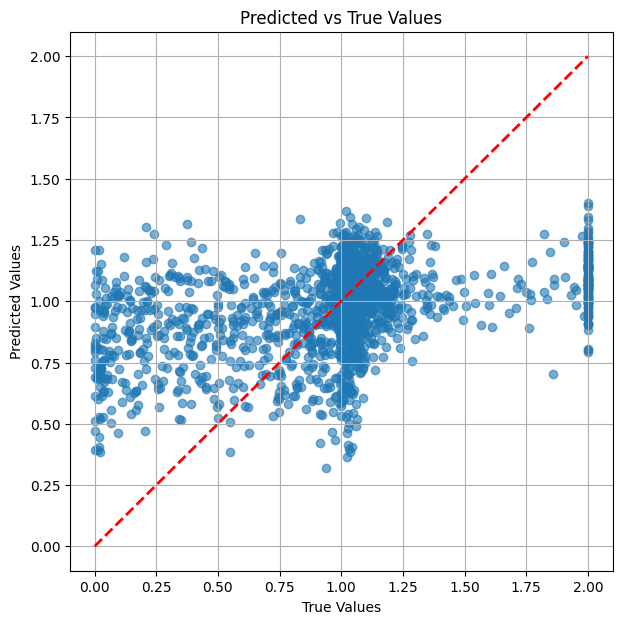

In [2502]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_reg, y_reg_pred, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [51]:
dec_tree_reg = DecisionTreeRegressor(random_state=42).fit(X_train_reg, y_train_reg)
y_reg_pred = dec_tree_reg.predict(X_test_reg)

In [52]:
# Side by side
result = np.column_stack((y_reg_pred, y_test_reg))

In [53]:
result

array([[0.18271, 0.59138],
       [1.     , 1.     ],
       [0.33407, 1.     ],
       ...,
       [1.     , 0.     ],
       [1.     , 1.     ],
       [1.     , 1.     ]], shape=(3043, 2))

In [54]:
mse = mean_squared_error(y_test_reg, y_reg_pred)
print("MSE:", mse)

MSE: 0.3171422113481433


In [55]:
dt = DecisionTreeRegressor(random_state=42)
param_grid = {
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,  # 5-fold cross-validation
                           scoring='neg_mean_squared_error',
                           n_jobs=-1)

# Fit Grid Search
grid_search.fit(X_train_reg, y_train_reg)


# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [56]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_reg)
mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)


Test MSE: 0.27619840008456836


Decision Tree Feature Importance:
 ob__avg_util_ref                             0.111173
ob__std_util_3m                              0.073961
ab__max_one_day_drop_6m                      0.056493
madrid__avg_monthly_expenses_3m              0.047175
mix__sd_od_history_to_kyc_ratio              0.044918
ob__avg_util_change_last2m_to_first2m_1y     0.044191
ob__max_to_avg_util_3m_ratio                 0.042360
madrid__avg_monthly_repayment_capacity_3m    0.042192
sd__age                                      0.040690
ab__bal_change_freq_3m                       0.035922
ob__limit_ref                                0.033489
ab__std_abs_change_6m                        0.033266
ab__inflow_spike_count_6m                    0.032514
sd__age_since_last_kyc                       0.032218
sd__max_daily_logins_6m                      0.030856
ob__avg_util_3m                              0.030781
ob__max_util_3m                              0.030119
madrid__avg_monthly_salary_3m                0.

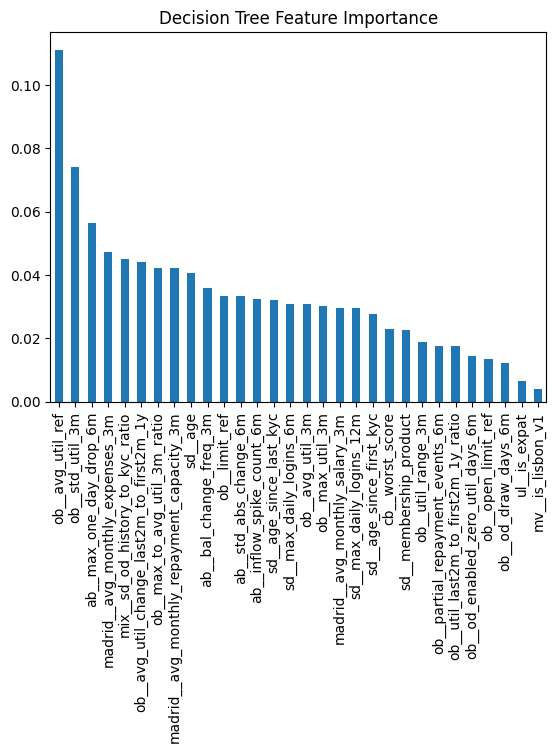

In [58]:
# Feature importance
importance_dt = pd.Series(dec_tree_reg.feature_importances_, index=X_train_reg.columns).sort_values(ascending=False)
print("Decision Tree Feature Importance:\n", importance_dt)

# Plot
importance_dt.plot(kind='bar', title='Decision Tree Feature Importance')
plt.show()

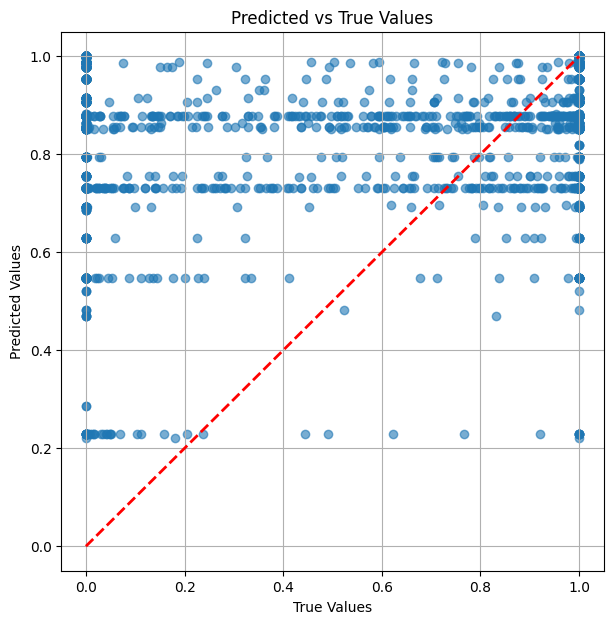

In [59]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_reg, y_pred, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [72]:
rdm_for_reg = RandomForestRegressor(random_state=42, n_estimators=1000).fit(X_train_reg, y_train_reg)
y_reg_pred = rdm_for_reg.predict(X_train_reg)

KeyboardInterrupt: 

In [82]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [83]:
param_dist = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5, 0.8],
    "bootstrap": [True, False]
}

In [84]:
from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,               # increase to 100 if time allows
    cv=5,
    scoring="neg_root_mean_squared_error",  # or "r2"
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_search.fit(X_train_reg, y_train_reg)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   5.2s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   5.2s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   5.2s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   5.3s
[CV] END bootstrap=False, max_depth=20, max_features=log2, min_samples_leaf=5, min_samples_split=20, n_estimators=300; total time=   5.3s
[CV] END bootstrap=False, max_depth=5, max_features=0.8, min_samples_leaf=1, min_samples_split=10, n_estimators=500; total time=  23.1s
[CV] END bootstrap=False, max_depth=5, max_features=0.8, min_samples_leaf=1, min_samples_split=10, n_estimators=

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,50
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [85]:
best_rf = rf_search.best_estimator_

print("Best parameters:")
print(rf_search.best_params_)

print("Best CV score:")
print(-rf_search.best_score_)

Best parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Best CV score:
0.2411433147765401


In [92]:
y_reg_pred = best_rf.predict(X_test_reg)

In [93]:
# Side by side
result = np.column_stack((y_reg_pred, y_test_reg))

In [94]:
result

array([[0.78096472, 0.59138   ],
       [0.87276579, 1.        ],
       [0.89252789, 1.        ],
       ...,
       [0.84881029, 0.        ],
       [0.95256546, 1.        ],
       [0.6700972 , 1.        ]], shape=(3043, 2))

In [95]:
mse = mean_squared_error(y_test_reg, y_reg_pred)
print("MSE:", mse)

MSE: 0.2693285469201486


Random Forest Feature Importance:
 ob__std_util_3m                              0.083141
ob__open_limit_ref                           0.066577
ob__avg_util_ref                             0.063896
mix__sd_od_history_to_kyc_ratio              0.048315
ob__avg_util_change_last2m_to_first2m_1y     0.046861
sd__age                                      0.044371
madrid__avg_monthly_expenses_3m              0.044072
madrid__avg_monthly_repayment_capacity_3m    0.039964
ab__max_one_day_drop_6m                      0.039825
ob__limit_ref                                0.036465
sd__age_since_first_kyc                      0.036345
ab__bal_change_freq_3m                       0.035535
ab__std_abs_change_6m                        0.035177
sd__max_daily_logins_6m                      0.034717
sd__age_since_last_kyc                       0.034306
ob__max_to_avg_util_3m_ratio                 0.032636
sd__max_daily_logins_12m                     0.030570
ob__max_util_3m                              0.

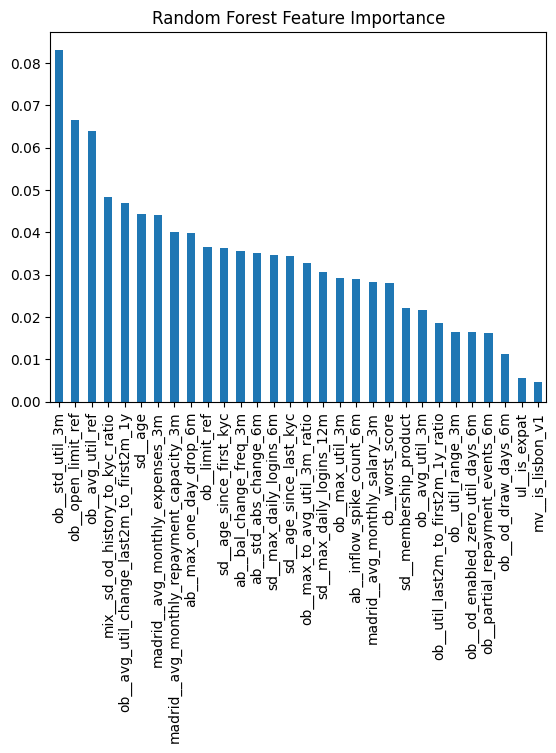

In [96]:
# Feature importance
importance_rf = pd.Series(rdm_for_reg.feature_importances_, index=X_train_reg.columns).sort_values(ascending=False)
print("Random Forest Feature Importance:\n", importance_rf)

# Plot
importance_rf.plot(kind='bar', title='Random Forest Feature Importance')
plt.show()

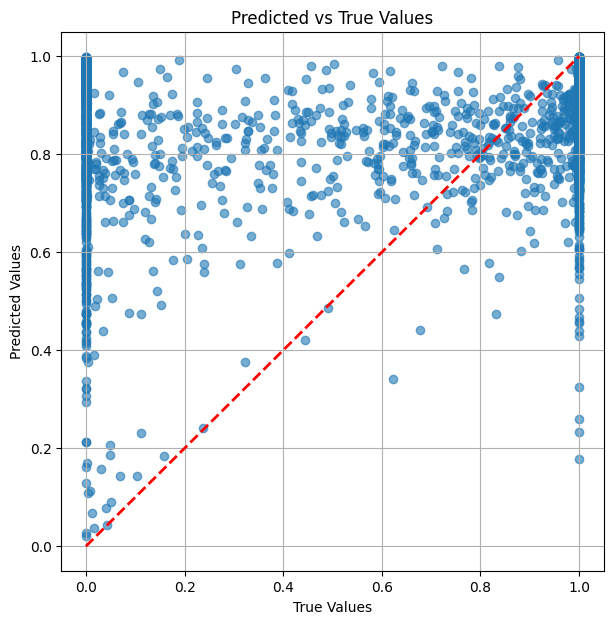

In [98]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_reg, y_reg_pred, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [26]:
xgb_reg = XGBRegressor(objective='reg:tweedie',  # correct string for Tweedie in XGBoost >=1.6
    tweedie_variance_power=1,
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1).fit(X_train_scaled, y_train_reg)
y_reg_pred = xgb_reg.predict(X_test_scaled)

In [2455]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train_reg)
y_reg_pred = xgb.predict(X_test_scaled)

In [100]:
from catboost import CatBoostRegressor

cat_reg = CatBoostRegressor(
    loss_function='Tweedie:variance_power=1.1',  # Tweedie with variance_power=1
    iterations=1000,
    learning_rate=0.01,
    depth=5,
    subsample=0.7,
    colsample_bylevel=0.9,  # similar to colsample_bytree
    random_seed=42,
    thread_count=-1,
    verbose=100  # prints progress
).fit(X_train_reg, y_train_reg)

y_reg_pred = cat_reg.predict(X_test_reg)


0:	learn: 9.6915272	total: 58.1ms	remaining: 58.1s
100:	learn: 9.6740997	total: 156ms	remaining: 1.39s
200:	learn: 9.6694826	total: 252ms	remaining: 1000ms
300:	learn: 9.6676752	total: 351ms	remaining: 814ms
400:	learn: 9.6665177	total: 446ms	remaining: 666ms
500:	learn: 9.6657462	total: 540ms	remaining: 538ms
600:	learn: 9.6650874	total: 832ms	remaining: 552ms
700:	learn: 9.6644594	total: 971ms	remaining: 414ms
800:	learn: 9.6639735	total: 1.07s	remaining: 265ms
900:	learn: 9.6634696	total: 1.16s	remaining: 128ms
999:	learn: 9.6630828	total: 1.26s	remaining: 0us


In [2067]:
import lightgbm as lgb

lgb_reg = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1,
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
).fit(X_train_scaled, y_train_reg)

y_reg_pred = lgb_reg.predict(X_test_scaled)

/Users/ilya.katliarou/Documents/CCF/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [101]:
# Side by side
result = np.column_stack((y_reg_pred, y_test_reg))

In [102]:
result[:10]

array([[0.76947496, 0.59138   ],
       [0.87693098, 1.        ],
       [0.86227322, 1.        ],
       [0.81620125, 0.        ],
       [0.94927482, 0.        ],
       [0.9829368 , 1.        ],
       [0.94855763, 1.        ],
       [0.87127632, 0.        ],
       [0.94512148, 0.        ],
       [0.85256491, 1.        ]])

In [29]:
X_test.iloc[7]

ob__limit_ref            250.0
ob__balance_ref            0.0
ob__avg_util_ref           0.0
ob__open_limit_ref         1.0
mv__is_lisbon_v1           1.0
                         ...  
dn__recent_action          NaN
dn__max_action_level       NaN
cb__most_recent_score      5.0
cb__worst_score            5.0
ep__cc_tbil_balance        0.0
Name: 4554, Length: 69, dtype: float64

In [103]:
mse = mean_squared_error(y_test_reg, y_reg_pred)
print("MSE:", mse)

MSE: 0.2689448496488352


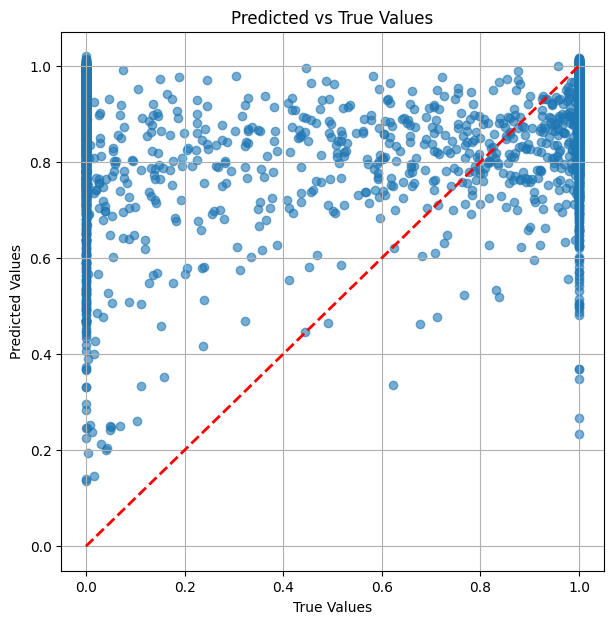

In [104]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_reg, y_reg_pred, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [2452]:
test = pd.concat([X_test.reset_index(drop=True), 
                    pd.Series(y_reg_pred, name='predicted_ccf'),
                    pd.Series(y_test_reg.reset_index(drop=True), name='realized_ccf')],
                   axis=1)

In [2453]:
test[((test['predicted_ccf']>0.6) & (test['realized_ccf']<0.25))]

,ob__limit_ref,ob__balance_ref,ob__avg_util_ref,ob__open_limit_ref,mv__is_lisbon_v1,madrid__avg_monthly_salary_3m,madrid__avg_monthly_expenses_3m,madrid__avg_monthly_repayment_capacity_3m,ul__account_age_months,ob__num_limit_increases_1y,ob__avg_util_0_1m,ob__avg_util_change_1m,ob__max_util_0_1m,ob__max_util_change_1m,ob__std_util_0_1m,ob__std_util_change_1m,ob__util_slope_3m,ob__util_range_3m,ob__overlimit_days_6m,ob__max_consecutive_od_days_1y,ab__avg_bal_0_1m,ab__avg_bal_change_1m,ab__max_util_0_1m,ab__max_bal_change_1m,ab__std_util_0_1m,ab__std_bal_change_1m,ab__bal_change_freq_1m,ab__mean_abs_change_6m,ab__std_abs_change_6m,ab__max_one_day_drop_6m,ab__income_spike_count_6m,ab__days_down_6m,ab__near_zero_days_6m,dn__recent_action,dn__max_action_level,cb__most_recent_score,cb__worst_score,ep__cc_balance,ep__tbil_balance,predicted_ccf,realized_ccf
4,8000.0,0.00,0.00000,1.00000,1,2155.006667,3737.530000,4545.756667,31.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.953820e-08,0.358920,5,278,596.810000,-4703.229409,2339.77,-8577.98,997.454354,-3671.436610,27,250.186575,690.773497,-19234.12,10,93,0,0.0,0.0,7.0,7.0,0.0,0.0,0.669165,0.16777
55,750.0,667.02,0.88936,0.11064,1,0.000000,65.175000,50.000000,55.0,0,0.887727,-0.016614,0.918226,0.008000,0.041614,0.031808,1.139407e-09,0.131333,0,366,-665.795806,12.607527,-590.17,71.25,31.210588,23.939088,3,2.560000,14.700249,-76.85,0,13,0,0.0,0.0,1.0,8.0,0.0,0.0,1.109411,0.20836
72,8000.0,0.00,0.00000,1.00000,1,0.000000,3737.530000,4545.756667,46.0,0,0.002432,0.002432,0.075404,0.075404,0.013543,0.013543,9.008515e-10,0.690558,0,9,596.810000,-5490.657301,2339.77,-45910.36,1018.620095,-8725.266809,25,250.186575,690.773497,-50000.00,10,120,0,0.0,0.0,5.0,5.0,0.0,0.0,0.608941,0.07897
79,250.0,0.00,0.00000,1.00000,1,0.000000,322.560000,557.716667,72.0,0,0.220587,0.143899,0.613520,0.177683,0.230956,0.105195,3.305485e-09,0.613520,0,24,-4.230000,-286.385667,266.13,-363.83,121.321767,-35.622696,13,32.378232,101.365394,-640.49,2,52,11,0.0,0.0,4.0,7.0,0.0,0.0,0.970694,0.00180
82,250.0,0.00,0.00000,1.00000,1,0.000000,118.235000,542.530000,1.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0,0,76.758710,14.521210,286.25,174.70,90.467308,34.538375,25,53.184412,63.978457,-200.00,0,17,14,0.0,0.0,7.0,7.0,0.0,0.0,1.260008,0.01700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2033,500.0,0.00,0.00000,1.00000,0,0.000000,484.186667,1172.290000,28.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0,0,596.810000,250.994473,1192.34,493.14,146.569234,58.368259,27,46.312928,62.827385,-286.16,0,108,0,0.0,0.0,1.0,9.0,0.0,0.0,0.769000,0.03812
2042,1500.0,0.00,0.00000,1.00000,1,0.000000,161.776667,-99.426667,53.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0,0,36.978387,-95.535613,93.33,-97.96,10.458417,-38.352395,1,19.843039,85.191136,-555.00,1,20,0,0.0,0.0,0.0,0.0,0.0,0.0,0.716720,0.13533
2091,6000.0,0.00,0.00000,1.00000,1,986.760000,2702.893333,4003.370000,13.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0,0,374.234839,-53.111828,1716.65,-187.86,472.260487,-38.834557,22,157.896077,280.731249,-1278.15,9,102,17,7.0,7.0,7.0,7.0,0.0,0.0,0.806854,0.18271
2097,6000.0,3738.43,0.62307,0.37693,1,0.000000,0.000000,0.000000,50.0,0,0.615904,0.013029,0.623071,0.020196,0.009823,0.009823,2.422533e-09,0.020196,0,366,-3695.430645,-78.180645,-3617.25,0.00,58.938736,58.938736,1,1.317293,12.498461,-121.18,0,2,0,0.0,0.0,7.0,7.0,0.0,0.0,0.630101,0.21718


In [1518]:
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1]
}

xgb = XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train_reg)

best_xgb = grid_search.best_estimator_
y_pred = np.clip(best_xgb.predict(X_test_scaled), 0, 3)

Fitting 3 folds for each of 162 candidates, totalling 486 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1; total time=   0.2s
[CV] END cols

In [2454]:
mse = mean_squared_error(y_test_reg, y_pred)
print("MSE:", mse)

MSE: 0.14411955729277254


In [1520]:
best_xgb

,objective,'reg:tweedie'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [1207]:
# Quantile regression: predict 50th percentile (median)
params = {
    'objective': 'quantile',
    'alpha': 0.5,  # 0.5 for median, 0.1 for lower quantile, 0.9 for upper
    'metric': 'quantile',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'max_bin': 255,
    'verbose': -1
}

lgb_train = lgb.Dataset(X_train_scaled, y_train_reg)
lgb_val = lgb.Dataset(X_test_scaled, y_test_reg, reference=lgb_train)

model_lgb = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val]
)

# Predict
y_pred = model_lgb.predict(X_test_scaled)
# Clip predictions to CCF bounds
y_pred = np.clip(y_pred, 0, 3)

# Evaluate
print("MAE:", mean_absolute_error(y_test_reg, y_pred))
print("MSE:", mean_squared_error(y_test_reg, y_pred))


MAE: 0.45545365593376136
MSE: 0.40361587186809916


In [1208]:
# Create pools
train_pool = Pool(X_train_scaled, y_train_reg)
val_pool = Pool(X_test_scaled, y_test_reg)

# CatBoost with quantile regression
model_cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Quantile:alpha=0.5',  # median
    eval_metric='MAE',
    early_stopping_rounds=50,
    verbose=100
)

model_cb.fit(train_pool, eval_set=val_pool)

# Predict
y_pred_cb = model_cb.predict(X_test_scaled)
y_pred_cb = np.clip(y_pred_cb, 0, 3)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_cb))
print("MSE:", mean_squared_error(y_test_reg, y_pred_cb))

0:	learn: 0.5257776	test: 0.5261956	best: 0.5261956 (0)	total: 6.07ms	remaining: 6.06s
100:	learn: 0.4525805	test: 0.4642443	best: 0.4642443 (100)	total: 185ms	remaining: 1.65s
200:	learn: 0.4369241	test: 0.4604892	best: 0.4604792 (199)	total: 355ms	remaining: 1.41s
300:	learn: 0.4220338	test: 0.4579387	best: 0.4579387 (300)	total: 514ms	remaining: 1.19s
400:	learn: 0.4105707	test: 0.4562744	best: 0.4562744 (400)	total: 679ms	remaining: 1.01s
500:	learn: 0.4014663	test: 0.4556550	best: 0.4554769 (464)	total: 843ms	remaining: 840ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4554769159
bestIteration = 464

Shrink model to first 465 iterations.
MAE: 0.4540998992079057
MSE: 0.40050558673109454


In [1396]:
# Create and train the SVR model
svr_model = SVR(kernel='rbf', C=0.25, epsilon=0.1).fit(X_train_scaled, y_train_reg)
y_reg_pred = svr_model.predict(X_test_scaled)

In [1397]:
# Side by side
result = np.column_stack((y_reg_pred, y_test_reg))

In [1398]:
result

array([[1.01528703, 1.30227   ],
       [0.97275239, 1.09352   ],
       [1.01108577, 1.42168   ],
       ...,
       [1.0983535 , 1.0595    ],
       [0.86745333, 1.10844   ],
       [0.98062725, 1.5       ]], shape=(2089, 2))

In [1399]:
mse = mean_squared_error(y_test_reg, y_reg_pred)
print("MSE:", mse)

MSE: 0.08583882084765379


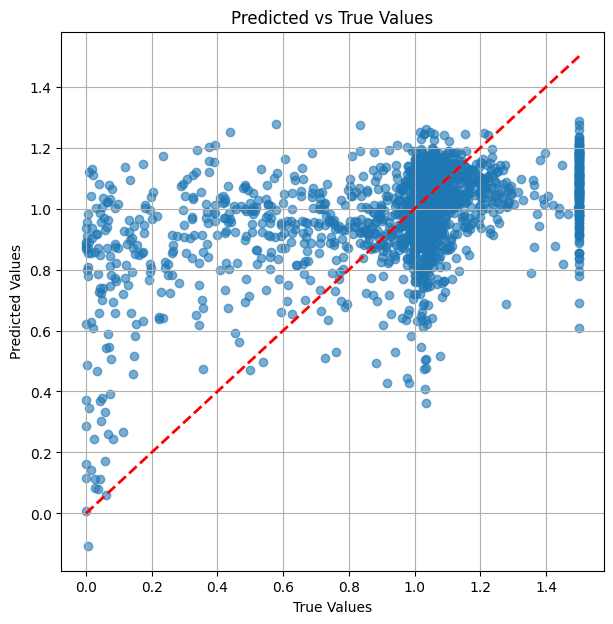

In [1400]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_reg, y_reg_pred, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color='red', linewidth=2, linestyle='--')  # y=x reference line
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True)
plt.show()

In [14]:
log_reg = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train_clf)
y_clf_pred = log_reg.predict(X_test_scaled)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [2382]:
# Side by side
result = np.column_stack((y_clf_pred, y_test_clf))

In [2383]:
result

array([[1, 1],
       [1, 1],
       [0, 0],
       ...,
       [1, 1],
       [0, 1],
       [1, 0]], shape=(3012, 2))

In [2384]:
# Accuracy
accuracy = accuracy_score(y_test_clf, y_clf_pred)

# Precision, Recall, F1
precision = precision_score(y_test_clf, y_clf_pred)
recall = recall_score(y_test_clf, y_clf_pred)
f1 = f1_score(y_test_clf, y_clf_pred)

# ROC-AUC (if binary classification)
roc_auc = roc_auc_score(y_test_clf, y_clf_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_clf_pred)

# Classification Report (all metrics in one)
report = classification_report(y_test_clf, y_clf_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.649734395750332
Precision: 0.6253521126760564
Recall: 0.5037821482602118
F1 Score: 0.5580226225387516
ROC AUC: 0.6338437368519995
Confusion Matrix:
 [[1291  399]
 [ 656  666]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.76      0.71      1690
           1       0.63      0.50      0.56      1322

    accuracy                           0.65      3012
   macro avg       0.64      0.63      0.63      3012
weighted avg       0.65      0.65      0.64      3012



In [2320]:
dec_tree_clf = DecisionTreeClassifier(random_state=42).fit(X_train_scaled, y_train_clf)
y_clf_pred = dec_tree_clf.predict(X_test_scaled)

In [2321]:
# Side by side
result = np.column_stack((y_clf_pred, y_test_clf))

In [2322]:
result

array([[1, 0],
       [1, 0],
       [1, 1],
       ...,
       [0, 0],
       [1, 1],
       [1, 1]], shape=(2126, 2))

In [1684]:
dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=dt,
                           param_grid=param_grid,
                           cv=5,  # 5-fold cross-validation
                           scoring='roc_auc',
                           n_jobs=-1)

# Fit Grid Search
grid_search.fit(X_train_scaled, y_train_clf)


# Best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [1685]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
ras = roc_auc_score(y_test_clf, y_pred)
print("Test ROC-AUC:", ras)

Test ROC-AUC: 0.6154398455815071


In [1686]:

# Accuracy
accuracy = accuracy_score(y_test_clf, y_clf_pred)

# Precision, Recall, F1
precision = precision_score(y_test_clf, y_clf_pred)
recall = recall_score(y_test_clf, y_clf_pred)
f1 = f1_score(y_test_clf, y_clf_pred)

# ROC-AUC (if binary classification)
roc_auc = roc_auc_score(y_test_clf, y_clf_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_clf_pred)

# Classification Report (all metrics in one)
report = classification_report(y_test_clf, y_clf_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.599502487562189
Precision: 0.684931506849315
Recall: 0.684931506849315
F1 Score: 0.684931506849315
ROC AUC: 0.5677217261209033
Confusion Matrix:
 [[132 161]
 [161 350]]

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.45      0.45       293
           1       0.68      0.68      0.68       511

    accuracy                           0.60       804
   macro avg       0.57      0.57      0.57       804
weighted avg       0.60      0.60      0.60       804



In [31]:
rdm_for_clf = RandomForestClassifier(random_state=42, n_estimators=1000).fit(X_train_scaled, y_train_clf)
y_clf_pred = rdm_for_clf.predict_proba(X_test_scaled)[:,1]

In [32]:
y_clf_pred

array([0.565, 0.827, 0.593, ..., 0.524, 0.543, 0.411], shape=(3107,))

In [33]:
# Side by side
result = np.column_stack((y_clf_pred, y_test_clf))

In [34]:
result

array([[0.565, 0.   ],
       [0.827, 1.   ],
       [0.593, 1.   ],
       ...,
       [0.524, 0.   ],
       [0.543, 1.   ],
       [0.411, 0.   ]], shape=(3107, 2))

In [35]:
# ROC-AUC (if binary classification)
roc_auc = roc_auc_score(y_test_clf, y_clf_pred)
roc_auc

0.6907939767282683

In [19]:
# Accuracy
accuracy = accuracy_score(y_test_clf, y_clf_pred)

# Precision, Recall, F1
precision = precision_score(y_test_clf, y_clf_pred)
recall = recall_score(y_test_clf, y_clf_pred)
f1 = f1_score(y_test_clf, y_clf_pred)

# ROC-AUC (if binary classification)
roc_auc = roc_auc_score(y_test_clf, y_clf_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_clf_pred)

# Classification Report (all metrics in one)
report = classification_report(y_test_clf, y_clf_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.7122626327647248
Precision: 0.7291897891231964
Recall: 0.9240506329113924
F1 Score: 0.815136476426799
ROC AUC: 0.5862552959218152
Confusion Matrix:
 [[ 242  732]
 [ 162 1971]]

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.25      0.35       974
           1       0.73      0.92      0.82      2133

    accuracy                           0.71      3107
   macro avg       0.66      0.59      0.58      3107
weighted avg       0.69      0.71      0.67      3107



In [2386]:
pos = (y_train_clf==1).sum()
neg = (y_train_clf==0).sum()

In [2387]:
xgb_clf = XGBClassifier(scale_pos_weight=neg/pos, use_label_encoder=False, eval_metric='auc', random_state=42, n_estimators=500, max_depth=7, learning_rate = 0.1).fit(X_train, y_train_clf)
y_clf_pred = xgb_clf.predict(X_test)

/Users/ilya.katliarou/Documents/CCF/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:49:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [2388]:
#y_clf_pred_xgb = xgb_clf.predict_proba(sampled_df)

In [2389]:
result = np.column_stack((y_clf_pred, y_test_clf))

In [2390]:
result

array([[1, 1],
       [1, 1],
       [0, 0],
       ...,
       [0, 1],
       [0, 1],
       [1, 0]], shape=(3012, 2))

In [2391]:
X_train

,ob__limit_ref,ob__balance_ref,ob__avg_util_ref,ob__open_limit_ref,mv__is_lisbon_v1,madrid__avg_monthly_salary_3m,madrid__avg_monthly_expenses_3m,madrid__avg_monthly_repayment_capacity_3m,ul__account_age_months,ob__num_limit_increases_1y,ob__avg_util_0_1m,ob__avg_util_change_1m,ob__max_util_0_1m,ob__max_util_change_1m,ob__std_util_0_1m,ob__std_util_change_1m,ob__util_slope_3m,ob__util_range_3m,ob__overlimit_days_6m,ob__max_consecutive_od_days_1y,ab__avg_bal_0_1m,ab__avg_bal_change_1m,ab__max_util_0_1m,ab__max_bal_change_1m,ab__std_util_0_1m,ab__std_bal_change_1m,ab__bal_change_freq_1m,ab__mean_abs_change_6m,ab__std_abs_change_6m,ab__max_one_day_drop_6m,ab__income_spike_count_6m,ab__days_down_6m,ab__near_zero_days_6m,dn__recent_action,dn__max_action_level,cb__most_recent_score,cb__worst_score,ep__cc_balance,ep__tbil_balance
14607,2400.00,2220.94,0.92539,0.07461,1,0.000000,0.000000,0.000000,42.0,0,0.925391,0.027928,0.925391,0.000000,1.846667e-16,-7.735390e-03,3.626661e-09,0.029996,0,366,-2120.940000,-64.791000,-2120.940,-71.99,5.316202e-13,-2.196621e+01,0,0.782597,7.425265,-71.990,0,2,0,0.0,0.0,7.0,7.0,0.0,0.000
8744,4250.00,3532.02,0.83106,0.16894,1,611.733333,745.783333,1231.090000,47.0,0,0.817466,0.057814,0.960171,0.051522,6.337302e-02,-2.625779e-03,2.630912e-08,0.449651,0,274,-3474.235806,-244.882473,-3049.580,-268.92,2.693358e+02,-6.317385e+00,23,93.973812,163.540150,-587.110,5,110,1,0.0,0.0,5.0,5.0,0.0,68.225
4289,250.00,0.00,0.00000,1.00000,1,0.000000,0.000000,500.000000,5.0,0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0,0,209.019032,-103.194301,403.310,-82.27,1.713610e+02,6.833418e+01,18,16.412203,57.862419,-100.000,1,74,26,0.0,0.0,6.0,6.0,0.0,0.000
5012,4250.00,4233.51,0.99612,0.00388,1,0.000000,153.326667,150.700000,72.0,0,0.993569,-0.004018,0.998687,-0.021550,2.294973e-03,-1.187280e-02,7.853400e-09,0.034779,21,366,-4227.828710,16.457957,-4201.060,-12.86,9.752925e+00,-4.950945e+01,6,7.847293,26.791610,-92.280,0,31,0,1.0,1.0,7.0,9.0,0.0,0.000
13556,250.00,249.28,0.99712,0.00288,1,0.000000,0.000000,62.500000,18.0,0,0.974691,-0.024031,0.997480,-0.022280,4.845400e-02,-4.750186e-03,2.751760e-08,0.221240,22,243,-243.672903,5.963430,-208.350,-4.71,1.211350e+01,-9.584641e-01,9,6.611657,33.190999,-157.300,0,34,0,7.0,7.0,3.0,4.0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5373,6000.00,5940.33,0.99006,0.00995,1,0.000000,470.550000,1188.266667,53.0,0,0.966688,0.157636,0.991101,0.099306,2.792571e-02,-6.058582e-02,-5.675879e-09,0.500000,6,366,-5800.134516,-1106.458183,-5408.450,-1537.49,1.675541e+02,-3.705843e+02,19,47.270110,228.482326,-397.260,1,81,0,0.0,0.0,5.0,6.0,0.0,68.225
13924,8000.00,4999.36,0.49994,0.50006,1,2306.170000,3992.607667,4608.872667,12.0,0,0.681379,0.157636,0.946213,0.058645,2.708264e-01,1.207057e-02,2.629420e-08,0.996603,0,191,-6427.754194,-3648.540527,-224.910,-4916.04,1.032908e+03,-5.582831e+02,27,259.220624,711.446256,-17635.620,10,121,0,0.0,0.0,2.0,2.0,0.0,0.000
5582,4805.95,0.00,0.00000,1.00000,1,0.000000,819.906667,4608.872667,72.0,0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0,0,727.554935,346.162984,2517.699,-4878.51,1.032908e+03,-6.581624e+03,27,259.220624,711.446256,-3348.330,4,121,0,0.0,0.0,0.0,7.0,0.0,68.225
889,6000.00,5825.47,0.97091,0.02909,1,51.500000,648.726667,365.396667,29.0,0,0.962861,-0.006329,0.970915,-0.029183,1.046205e-02,-1.983062e-02,2.751760e-08,0.310922,13,181,-5777.172581,31.153419,-5610.530,-9.94,6.277183e+01,-1.196878e+02,3,160.353094,581.507686,-4607.080,8,41,1,7.0,7.0,3.0,3.0,0.0,0.000


<Figure size 1000x800 with 0 Axes>

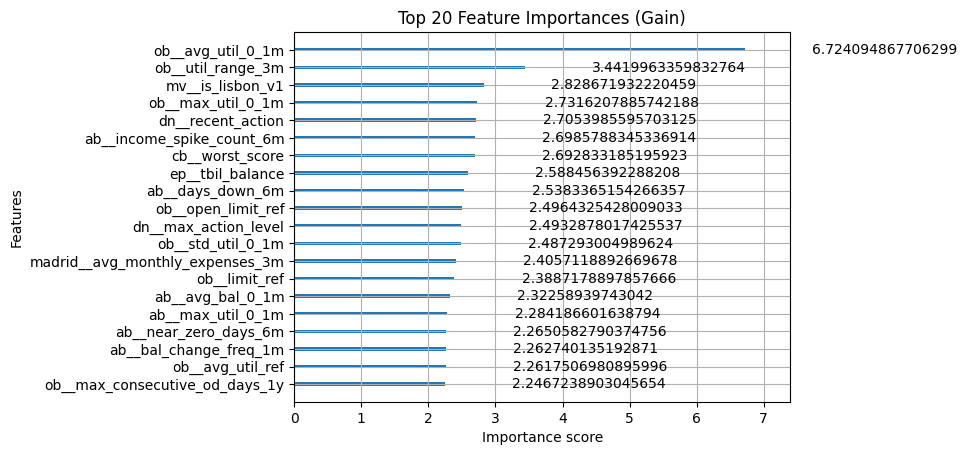

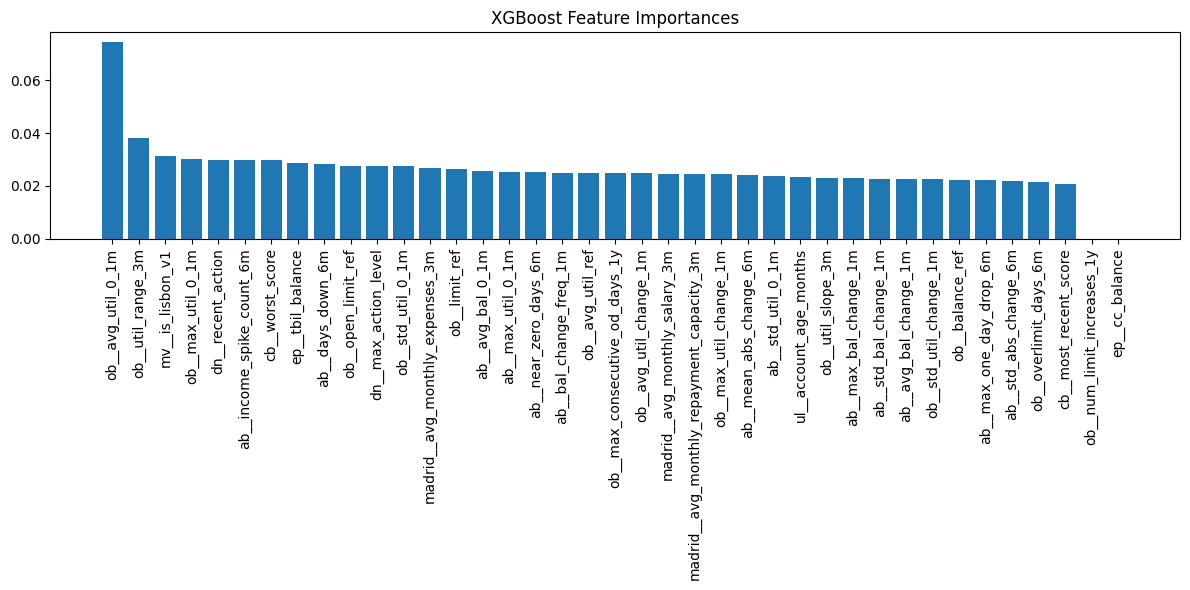

In [2392]:
from xgboost import plot_importance
# --- Method 1: Using XGBoost plot_importance ---
plt.figure(figsize=(10, 8))
plot_importance(xgb_clf, importance_type='gain', max_num_features=20)
plt.title("Top 20 Feature Importances (Gain)")
plt.show()

# --- Method 2: Access feature_importances_ directly ---
# This returns normalized importance (sum=1)
importances = xgb_clf.feature_importances_
feature_names = X_train.columns

# Create a sorted bar plot
sorted_idx = importances.argsort()[::-1]
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[sorted_idx], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in sorted_idx], rotation=90)
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [1579]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

# Define the base XGBClassifier
xgb_clf = XGBClassifier(
    eval_metric='auc',   # for binary classification
    random_state=42
)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1],
    'min_child_weight': [1, 5, 10]
}

# GridSearchCV setup
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='roc_auc',  # optimize for AUC
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train_clf)

# Best estimator
best_xgb_clf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# Predict on test set
y_clf_pred = best_xgb_clf.predict(X_test_scaled)
y_clf_proba = best_xgb_clf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
auc = roc_auc_score(y_test_clf, y_clf_proba)
acc = accuracy_score(y_test_clf, y_clf_pred)
print("Test AUC:", auc)
print("Test Accuracy:", acc)


Fitting 3 folds for each of 729 candidates, totalling 2187 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=1; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=1; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=300, subsample=0.7; total t

KeyboardInterrupt: 

In [2393]:
#y_hurdle = y_clf_pred_xgb[:,1] * y_reg_pred_xgb

In [2394]:
#mean_squared_error(y_realized, y_hurdle)

In [2395]:
# Accuracy
accuracy = accuracy_score(y_test_clf, y_clf_pred)

# Precision, Recall, F1
precision = precision_score(y_test_clf, y_clf_pred)
recall = recall_score(y_test_clf, y_clf_pred)
f1 = f1_score(y_test_clf, y_clf_pred)

# ROC-AUC (if binary classification)
roc_auc = roc_auc_score(y_test_clf, y_clf_pred)

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_clf_pred)

# Classification Report (all metrics in one)
report = classification_report(y_test_clf, y_clf_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc_auc)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.649734395750332
Precision: 0.6107883817427386
Recall: 0.556732223903177
F1 Score: 0.5825089038385437
ROC AUC: 0.6396087155018845
Confusion Matrix:
 [[1221  469]
 [ 586  736]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.72      0.70      1690
           1       0.61      0.56      0.58      1322

    accuracy                           0.65      3012
   macro avg       0.64      0.64      0.64      3012
weighted avg       0.65      0.65      0.65      3012

